In [1]:
import numpy as np
from PIL import Image

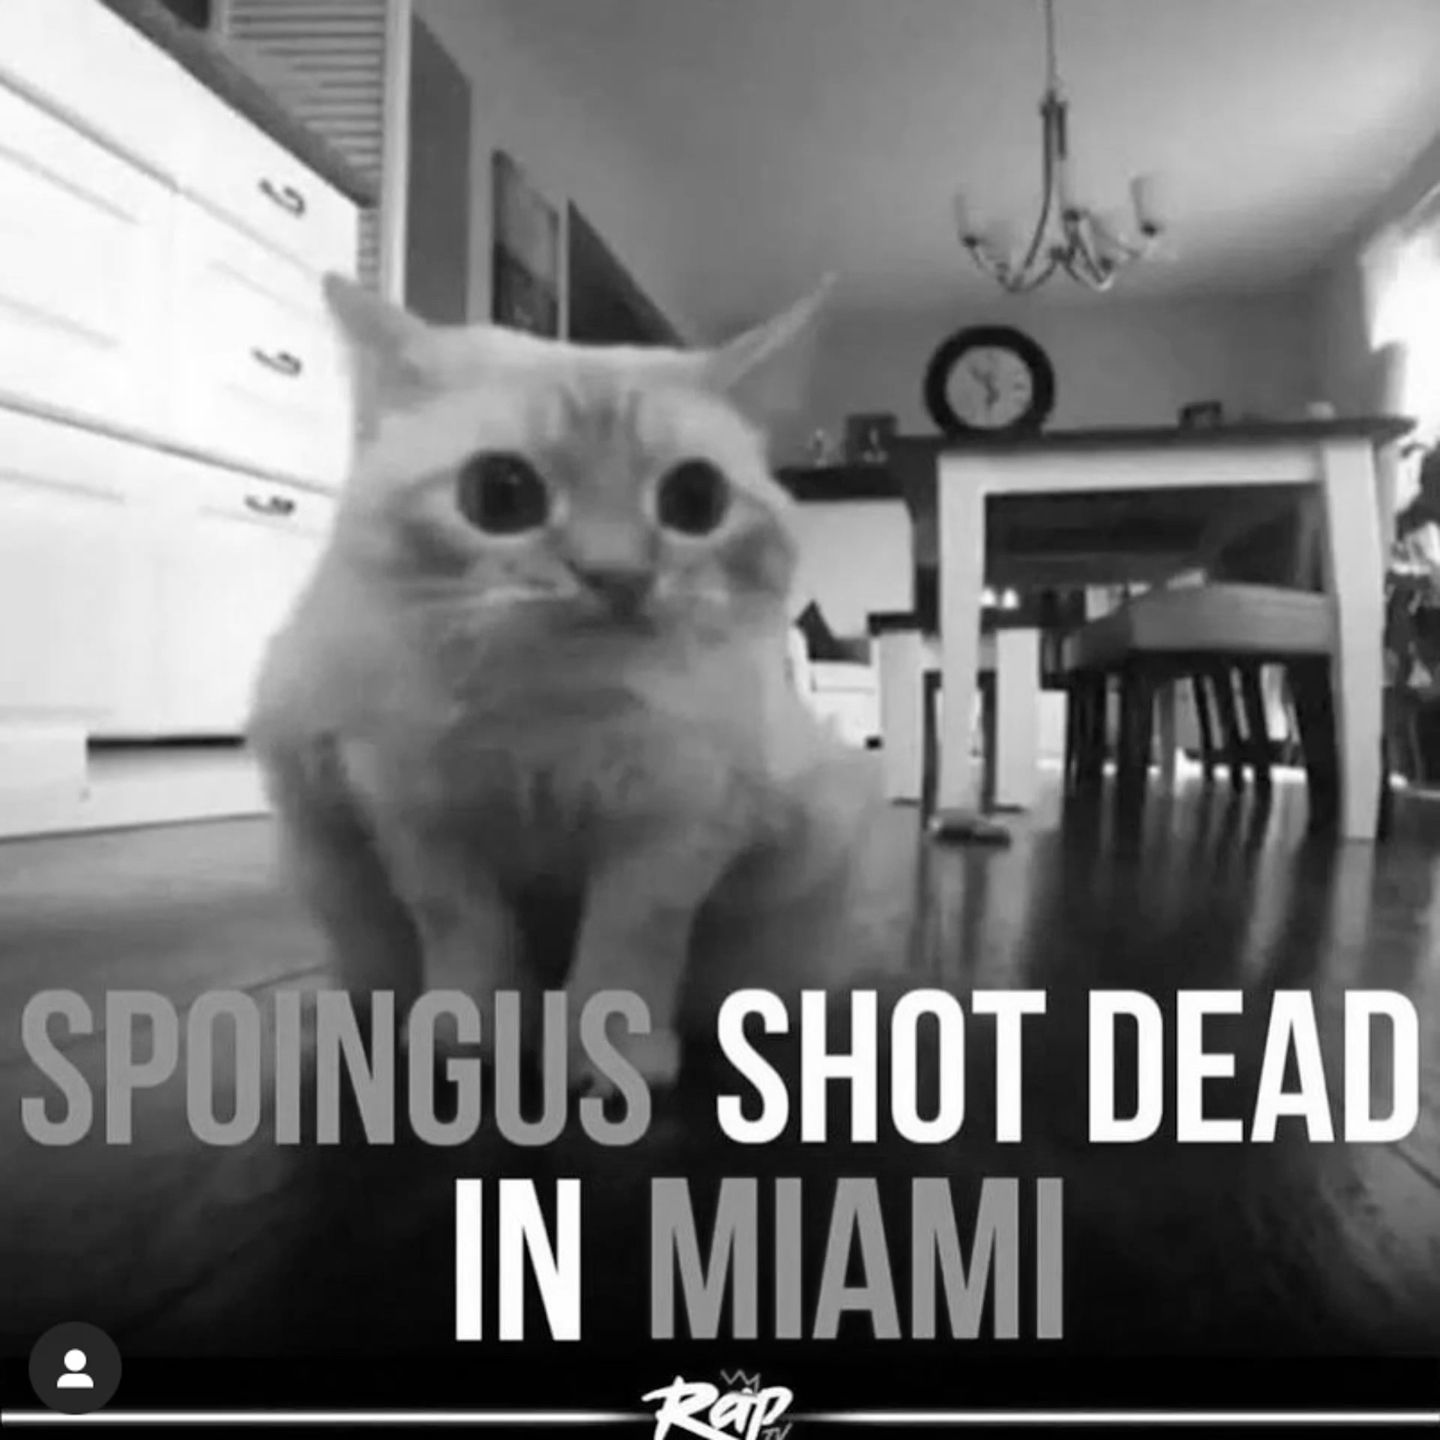

In [2]:
image = Image.open('9b317a0f1736e258ec9b901ae774ecce.jpg')

image = image.convert("L")

image

**Affine transformation**

In [3]:
mat = np.array(image)

In [4]:
mat.shape

(1440, 1440)

In [5]:
def translation(x, y, img_size): #centering image
    x1 = x - img_size[0]/2
    y1 = y - img_size[1]/2
    return x1, y1


In [6]:
def inverse(x, y, img_size): #reversing translation
    x2 = x + img_size[0]/2
    y2 = y + img_size[1]/2
    return x2, y2

In [7]:
def transformation(x, y, degree): #rotation 
    radians = np.radians(degree)
    x3 = np.cos(radians)*x - np.sin(radians)*y
    y3 = np.sin(radians)*x + np.cos(radians)*y
    return x3, y3

In [8]:
null_matrix = np.zeros(mat.shape) 

In [9]:
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        tx, ty = translation(i, j, mat.shape)
        t_x, t_y = transformation(tx, ty, 40)
        inv_x, inv_y = inverse(t_x, t_y, mat.shape) # transformation --> inverse
        conv1 = int(inv_x) #pixel position
        conv2 = int(inv_y)
        if (conv1 >= mat.shape[0]) or (conv2 >= mat.shape[1]) or (conv1 < 0) or (conv2 < 0):
            continue
        null_matrix[conv1][conv2] = mat[i][j]

In [10]:
i = Image.fromarray(null_matrix)
i.show()

In [11]:
def shear_transform(x, y, shx, shy, sx, sy):
    x3 = sx * x + shx * y
    y3 = shy * x + sy * y
    return x3, y3

null_matrix = np.zeros(mat.shape)

In [12]:
null_matrix = np.zeros(mat.shape)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        tx, ty = translation(i, j, mat.shape)
        t_x, t_y = shear_transform(tx, ty, 0.3, -0.5, 0, 0)
        inv_x, inv_y = inverse(t_x, t_y, mat.shape) # transformation --> inverse
        conv1 = int(inv_x) #pixel position
        conv2 = int(inv_y)
        if (conv1 >= mat.shape[0]) or (conv2 >= mat.shape[1]) or (conv1 < 0) or (conv2 < 0):
            continue
        null_matrix[conv1][conv2] = mat[i][j]

In [13]:
i = Image.fromarray(null_matrix)
i.show()

**Projective transformation**

In [15]:
def homography_4pts(src_pts, dst_pts):

    src_pts = np.asarray(src_pts, dtype=float)
    dst_pts = np.asarray(dst_pts, dtype=float)

    if src_pts.shape != (4, 2) or dst_pts.shape != (4, 2):
        raise ValueError("src_pts and dst_pts must both be shape (4,2).")
    
    A = []
    for (x, y), (u, v) in zip(src_pts, dst_pts):
        # x=row, y=col  |  u=row', v=col'
        A.append([x, y, 1,  0, 0, 0,  -u*x, -u*y, -u])
        A.append([0, 0, 0,  x, y, 1,  -v*x, -v*y, -v])

    A = np.asarray(A, dtype=float)

    _, _, Vt = np.linalg.svd(A)
    h = Vt[-1, :]
    H = h.reshape(3, 3)

    # normalize scale
    if abs(H[2, 2]) > 1e-12:
        H = H / H[2, 2]

    return H

In [16]:
def bilinear_sample(img, x, y):
    H, W = img.shape
    x0 = int(np.floor(x))
    y0 = int(np.floor(y))
    x1 = x0 + 1
    y1 = y0 + 1

    if x0 < 0 or y0 < 0 or x1 >= H or y1 >= W:
        return 0.0

    dx = x - x0
    dy = y - y0

    p00 = img[x0, y0]
    p10 = img[x1, y0]
    p01 = img[x0, y1]
    p11 = img[x1, y1]

    return (p00 * (1 - dx) * (1 - dy) +
            p10 * dx       * (1 - dy) +
            p01 * (1 - dx) * dy +
            p11 * dx       * dy)

In [17]:
def warp_projective(src_img, H, out_shape):
    Hd, Wd = out_shape
    out = np.zeros((Hd, Wd), dtype=float)

    Hinv = np.linalg.inv(H)

    for i in range(Hd):       # i=row in output
        for j in range(Wd):   # j=col in output
            dst = np.array([i, j, 1.0], dtype=float)
            src = Hinv @ dst

            w = src[2]
            if abs(w) < 1e-12:
                continue

            x = src[0] / w
            y = src[1] / w

            out[i, j] = bilinear_sample(src_img, x, y)

    return np.clip(out, 0, 255).astype(np.uint8)


In [19]:
Hh, Ww = mat.shape
src_pts = np.array([
    [50, 50],                # top-left
    [50, Ww-50],              # top-right
    [Hh-50, Ww-50],           # bottom-right
    [Hh-50, 50]               # bottom-left
], dtype=float)

dst_pts = np.array([
    [120, 120],                # top-left moves inward
    [40, Ww-120],              # top-right moves inward (different amount)
    [Hh-40, Ww-60],            # bottom-right
    [Hh-80, 60]                # bottom-left
], dtype=float)

H = homography_4pts(src_pts, dst_pts)
warped = warp_projective(mat, H, mat.shape)

Image.fromarray(warped).show()


**Filters on Numericals**

In [1]:
import numpy as np
def median(patch3x3):
    a = np.array(patch3x3).reshape(3,3)
    return int(np.median(a))

In [2]:
S_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
S_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

def sobel_3x3(patch3X3):
    I = np.array(patch3X3).reshape(3,3)
    gx = np.sum(S_x * I)
    gy = np.sum(S_y * I)
    mag = (gx**2 + gy**2)**0.5
    return gx, gy, mag

In [4]:
def convolve(img, kernel):
    img = np.array(img, dtype=float)
    k = np.array(kernel, dtype=float)
    kh, kw = k.shape
    H, W = img.shape
    out = np.zeros((H-kh+1, W-kw+1), dtype=float)
    for i in range(H-kh+1):
        for j in range(W-kw+1):
            out[i, j] = np.sum(img[i:i+kh, j:j+kw] * k)
    return out

def gaussian_thn_sobel(img, gaussian_kernel):
    sm = convolve(img, gaussian_kernel)
    gx = convolve(sm, S_x)
    gy = convolve(sm, S_y)
    mag = np.sqrt(gx**2 + gy**2)
    return sm, gx, gy, mag

In [5]:
def guassian_5x5():
    sigma = 2
    ax = np.arange(-2,3)
    g = np.zeros((5,5), dtype=float)
    for i, y in enumerate(ax):
        for j, x in enumerate(ax):
            g[i,j] = (1/(2*np.pi*sigma**2)) * np.exp(-(x*x + y*y)/(2*sigma**2))
    g /= g.sum()
    return g